In [58]:
import numpy as np
import torch
from Plotting import *
from matplotlib import pyplot as plt

../Results/0u0y7zwn/RMSE_over_time.pdf


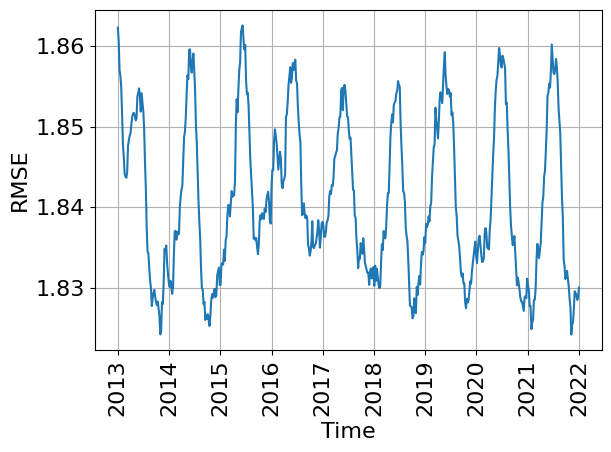

In [64]:
# RMSE over time
model = "0u0y7zwn"

rmses = torch.load(f"../Results/{model}/RMSE_over_time.pt", weights_only=True)
rmses = np.array(rmses)

def exponential_moving_average(data, alpha):
    ema = [data[0]]
    for value in data[1:]:
        ema.append(alpha * value + (1 - alpha) * ema[-1])
    return np.array(ema)

B = 24
batches = rmses.reshape((-1,B))
batch_means= batches.mean(axis=-1)

smooth = exponential_moving_average(batch_means, alpha=.05)
plot_RMSE_over_time(smooth)
plot_io(show=True, save_name=f"../Results/{model}/RMSE_over_time")